In [5]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import Cityscapes
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import numpy as np

# Importer les fonctions de ton fichier utils.py
from utils import threshold_CRC, miscoverage_loss

# ==========================================
# 1. CONFIGURATION
# ==========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ROOT_DIR = "/home/demarsac/Documents/coding/Unet/cityscapes" # <-- À MODIFIER
MODEL_PATH = "unet_cityscapes.pth"
NUM_CLASSES = 19

# Paramètres de la prédiction conforme
ALPHA = 0.05             # Risque toléré : 5% d'erreur de couverture
CALIBRATION_SIZE = 100   # Nombre d'images pour la calibration

In [6]:
from pathlib import Path
import os
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Chemins explicites vers les dossiers Cityscapes utilises
LEFTIMG8BIT_DIR = Path("/home/demarsac/Documents/coding/Unet/cityscapes/leftImg8bit")
GTFINE_DIR = Path("/home/demarsac/Documents/coding/Unet/cityscapes/gtFine_trainvaltest/gtFine")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 2. PRÉPARATION DU DATASET (Même logique que l'entraînement)
# ==========================================
valid_classes = [7, 8, 11, 12, 13, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33]
class_map = dict(zip(valid_classes, range(19)))

def map_cityscapes_labels(mask):
    mask = np.array(mask)
    mask_mapped = np.full(mask.shape, 255, dtype=np.uint8)
    for raw_id, train_id in class_map.items():
        mask_mapped[mask == raw_id] = train_id
    return mask_mapped

val_transform = A.Compose([
    A.Resize(256, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class CityscapesCalibration(Dataset):
    def __init__(self, left_root, gt_root, split, transform):
        self.left_root = Path(left_root).expanduser().resolve()
        self.gt_root = Path(gt_root).expanduser().resolve()
        self.split = split
        self.custom_transform = transform

        self.images_dir = self.left_root / split
        self.targets_dir = self.gt_root / split

        if not self.images_dir.exists() or not self.targets_dir.exists():
            raise RuntimeError(
                f"Split manquant pour la calibration: {split}. "
                f"Attendu: {self.images_dir} et {self.targets_dir}"
            )

        self.samples = []
        for city_dir in sorted(p for p in self.images_dir.iterdir() if p.is_dir()):
            target_city_dir = self.targets_dir / city_dir.name
            if not target_city_dir.exists():
                continue
            for image_path in sorted(city_dir.glob("*_leftImg8bit.png")):
                stem = image_path.name.replace("_leftImg8bit.png", "")
                mask_path = target_city_dir / f"{stem}_gtFine_labelIds.png"
                if mask_path.exists():
                    self.samples.append((image_path, mask_path))

        if not self.samples:
            raise RuntimeError(f"Aucun échantillon trouvé pour le split {split}.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, mask_path = self.samples[index]
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)
        mask = map_cityscapes_labels(mask)
        augmented = self.custom_transform(image=np.array(image), mask=mask)
        return augmented['image'], augmented['mask'].long()

# On utilise le split 'cal' comme set de calibration
calib_dataset = CityscapesCalibration(
    left_root=LEFTIMG8BIT_DIR,
    gt_root=GTFINE_DIR,
    split='cal',
    transform=val_transform,
 )
calib_loader = DataLoader(
    calib_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=max(1, min(8, os.cpu_count() or 4)),
    pin_memory=(DEVICE == "cuda"),
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=False,
    )

In [7]:
# ==========================================
# 3. CHARGEMENT DU MODÈLE
# ==========================================
print(f"Chargement du modèle depuis {MODEL_PATH}...")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None, # Pas besoin des poids ImageNet, on charge nos propres poids
    in_channels=3,
    classes=NUM_CLASSES
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
model.to(DEVICE)

Chargement du modèle depuis unet_cityscapes.pth...


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [10]:
# ==========================================
# 4. EXTRACTION DES PROBABILITÉS (CALIBRATION)
# ==========================================
proba_list = []
Y_list = []

# On choisit explicitement des indices de calibration pour pouvoir garder des points "non vus"
num_available = len(calib_dataset)
num_calibration = min(CALIBRATION_SIZE, num_available)
rng = np.random.default_rng(42)
calibration_indices = rng.choice(num_available, size=num_calibration, replace=False)
calibration_indices_set = set(int(i) for i in calibration_indices)

print(
    f"Extraction des prédictions sur {num_calibration} images de calibration "
    f"(sur {num_available} disponibles) sur {DEVICE}..."
 )

with torch.no_grad():
    for idx in calibration_indices:
        image_tensor, mask_tensor = calib_dataset[int(idx)]
        images = image_tensor.unsqueeze(0).to(DEVICE, non_blocking=True)
        masks = mask_tensor.unsqueeze(0).to(DEVICE, non_blocking=True)

        # Inférence avec précision mixte (optionnel mais plus rapide)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
            logits = model(images)
            probs = F.softmax(logits, dim=1)

        # Conversion des masques (0-18) en One-Hot (K, H, W)
        valid_masks = torch.clamp(masks, 0, NUM_CLASSES - 1)
        masks_one_hot = F.one_hot(valid_masks, num_classes=NUM_CLASSES)
        masks_one_hot = masks_one_hot.permute(0, 3, 1, 2)

        # Masque pour exclure les pixels 255 (à ignorer)
        valid_pixels_mask = (masks != 255).unsqueeze(1)

        p = probs[0].cpu().numpy()
        y = masks_one_hot[0].cpu().numpy()
        v = valid_pixels_mask[0].cpu().numpy()

        # Ne garder que les pixels valides
        proba_list.append(p * v)
        Y_list.append(y * v)

print(f"Extraction terminée : {len(proba_list)} images en mémoire.")

Extraction des prédictions sur 100 images de calibration (sur 500 disponibles) sur cuda...
Extraction terminée : 100 images en mémoire.


In [11]:
# ==========================================
# 5. CALCUL DE LAMBDA_HAT
# ==========================================
print(f"Lancement de la recherche dichotomique (Alpha = {ALPHA})...")

lambda_hat = threshold_CRC(
    alpha=ALPHA, 
    proba_list=proba_list, 
    Y_list=Y_list, 
    loss_func=miscoverage_loss
)

print("\n" + "="*40)
print("=== CALIBRATION TERMINÉE ===")
print("="*40)
print(f"Seuil de risque optimal (lambda_hat) : {lambda_hat:.5f}")
print("Tu peux maintenant utiliser ce seuil pour l'inférence !")

Lancement de la recherche dichotomique (Alpha = 0.05)...

=== CALIBRATION TERMINÉE ===
Seuil de risque optimal (lambda_hat) : 0.92348
Tu peux maintenant utiliser ce seuil pour l'inférence !


Indice non vu utilisé: 0
Lambda_hat: 0.92348
Varisco min/max: 1.0 / 7.0


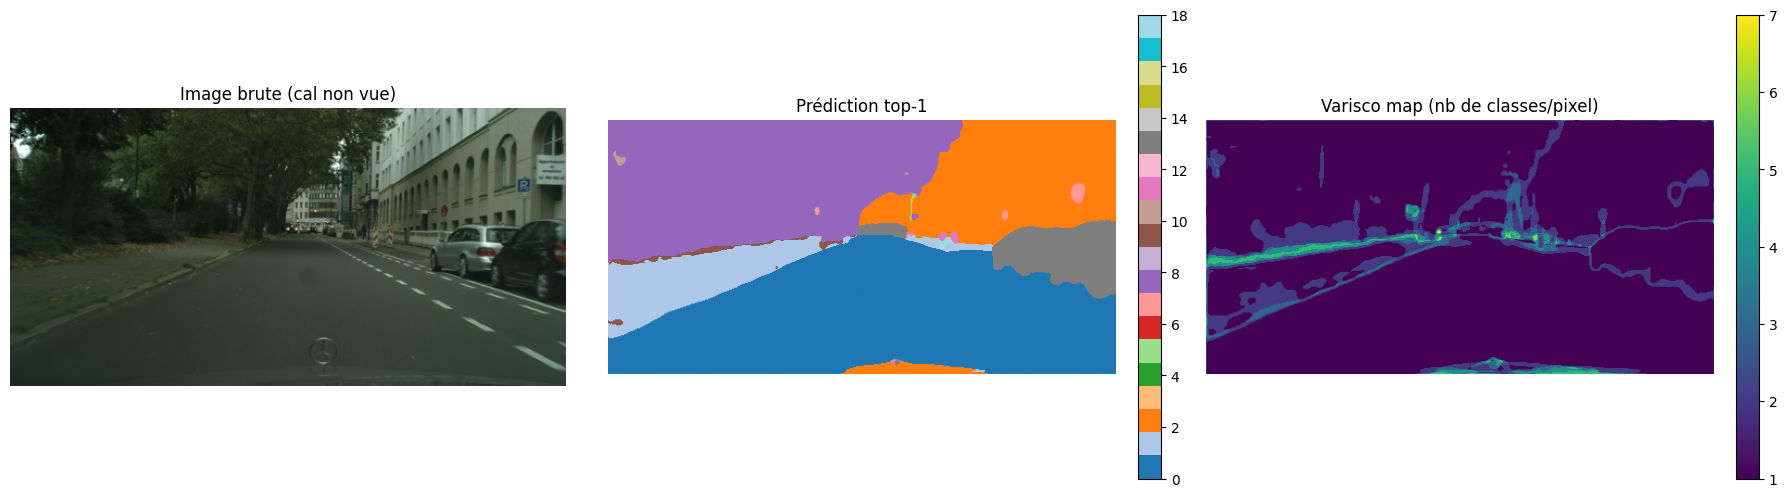

In [12]:
# ==========================================
# 6. INFÉRENCE SUR UN POINT NON VU + VARISCO MAP
# ==========================================
import matplotlib.pyplot as plt
from PIL import Image
from utils import thresholding

if len(calib_dataset) <= len(calibration_indices_set):
    raise RuntimeError(
        "Pas assez d'images dans le split cal pour choisir un point non vu."
    )

# Choisir un indice hors calibration
all_indices = np.arange(len(calib_dataset))
candidate_indices = np.array([i for i in all_indices if i not in calibration_indices_set])
unseen_idx = int(candidate_indices[0])

# Récupérer image + masque (transformés)
image_tensor, mask_tensor = calib_dataset[unseen_idx]
images = image_tensor.unsqueeze(0).to(DEVICE, non_blocking=True)

# Inférence
with torch.no_grad():
    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
        logits = model(images)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()  # (K, H, W)

# Ensemble conforme et varisco map
Z = thresholding(probs, lambda_hat)  # (K, H, W) binaire
varisco_map = Z.sum(axis=0)          # (H, W): nombre de classes gardées
top1_map = np.argmax(probs, axis=0)

# Image RGB brute pour visualisation
img_path, _ = calib_dataset.samples[unseen_idx]
img_raw = np.array(Image.open(img_path).convert("RGB").resize((512, 256)))

print(f"Indice non vu utilisé: {unseen_idx}")
print(f"Lambda_hat: {lambda_hat:.5f}")
print(f"Varisco min/max: {varisco_map.min()} / {varisco_map.max()}")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(img_raw)
ax[0].set_title("Image brute (cal non vue)")
ax[0].axis("off")

im1 = ax[1].imshow(top1_map, vmin=0, vmax=NUM_CLASSES - 1, cmap="tab20")
ax[1].set_title("Prédiction top-1")
ax[1].axis("off")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(varisco_map, cmap="viridis")
ax[2].set_title("Varisco map (nb de classes/pixel)")
ax[2].axis("off")
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()